# AIPW-HAL IPCW Prototype

This notebook is a notebook-local prototype for a separate AIPW-HAL estimator under right censoring.

The goals are:
- keep the Stage 1 IPCW-HAL nuisance fit unchanged;
- avoid any package API changes;
- prove what `_tmle_eif_values(0.0, ...)` represents before using it as an AIPW correction;
- compare the resulting AIPW estimate to the existing pointwise TMLE on the same nuisance fits.

The first deliverable is a semantic identity check, not a package abstraction.

In [1]:
import os
import sys
import pathlib
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import truncnorm

ROOT = pathlib.Path.cwd().resolve()
for candidate in [ROOT, ROOT.parent, ROOT.parent.parent, ROOT.parent.parent.parent]:
    src_path = candidate / "src"
    if src_path.exists() and str(src_path) not in sys.path:
        sys.path.append(str(src_path))

os.environ.setdefault("MPLCONFIGDIR", str((ROOT / ".matplotlib").resolve()))

from haldensity.censoring.right.estimators import RightCensoredInitEstimator
from haldensity.censoring.right.km import KaplanMeier
from haldensity.censoring.right.weights import compute_ipcw_weights
from haldensity.censoring.tuners.right_tuners import RightCensoredInitTuner
from haldensity.targeting import right_censored_survival_aipw, right_censored_survival_targeting_M_step
from haldensity.targeting.right_censored_survival.learner import (
    _build_censoring_cache,
    _build_initial_fit,
    _build_pointwise_target_grid,
    _compute_dfg_t0_on_grid,
    _interp_direction,
    _interp_survival_from_edges,
    _tmle_eif_values,
    _tmle_score_t0,
)

RNG_SEED = 6323852
N = 80
CV_FOLDS = 4
N_TRIALS = 6
N_GRID_POINTS = 160
BASIS_ORDER_OPTIONS = [1]
GBAR_CLIP = 1e-6
SURVIVAL_CLIP = 1e-8
EPS_BRACKET_START = 0.25
EPS_BRACKET_GROWTH = 2.0
EPS_BRACKET_MAX = 16.0
EPS_FALLBACK_BOUNDS = (-90.0, 90.0)
FOCUS_T0S = np.array([0.45, 0.85])
TARGET_TIMES = np.linspace(0.05, 0.95, 15)

np.random.seed(RNG_SEED)

## Shared Nuisance Fits

All target times in this notebook reuse the same nuisance objects:
- one reverse Kaplan-Meier fit for censoring;
- one IPCW-HAL Stage 1 fit for the event-time density;
- only the target-specific grid augmentation and the censoring-adjusted direction vary with `t0`.

That keeps the AIPW and TMLE comparisons on the same footing.

In [2]:
event_mean = 0.5
event_std = 0.15
lower, upper = 0.0, 1.0
a = (lower - event_mean) / event_std
b = (upper - event_mean) / event_std

event_times = truncnorm.rvs(
    a,
    b,
    loc=event_mean,
    scale=event_std,
    size=N,
    random_state=np.random.default_rng(RNG_SEED),
)
censor_times = np.random.default_rng(RNG_SEED + 1).uniform(0.0, 1.0, size=N)
tilde_T = np.minimum(event_times, censor_times)
Delta = (event_times <= censor_times).astype(int)
data = pd.DataFrame({"T": tilde_T, "Delta": Delta})

init_tuner = RightCensoredInitTuner(
    data=data,
    cv_folds=CV_FOLDS,
    n_grid_points=N_GRID_POINTS,
    silent=True,
)
init_tuner.param_overrides = {"basis_order": BASIS_ORDER_OPTIONS}
tuned_init = init_tuner.optimize(n_trials=N_TRIALS)

km_shared = KaplanMeier().fit(data, time_col="T", delta_col="Delta")
shared_weights = compute_ipcw_weights(
    T=data["T"].to_numpy(),
    Delta=data["Delta"].to_numpy(),
    S_c_predict=lambda t: np.atleast_1d(km_shared.predict(t)),
    clip=GBAR_CLIP,
)
uncensored_mask = data["Delta"].to_numpy() == 1
uncensored_df = pd.DataFrame({"W1": data.loc[uncensored_mask, "T"].to_numpy()})

stage1_estimator = RightCensoredInitEstimator(
    tol=tuned_init.estimator.tol,
    norm_constraint=float(tuned_init.best_params["norm_constraint"]),
    n_grid_points=N_GRID_POINTS,
    basis_order=int(tuned_init.best_params["basis_order"]),
    solver=tuned_init.estimator.solver,
    use_secondary_solver=tuned_init.estimator.use_secondary_solver,
)
stage1_estimator.fit(uncensored_df, sample_weights=shared_weights[uncensored_mask])

initial_fit = _build_initial_fit(stage1_estimator)
censoring_cache = _build_censoring_cache(km_shared, clip=GBAR_CLIP)

setup_summary = pd.Series(
    {
        "n": int(N),
        "uncensored": int(Delta.sum()),
        "censored": int(N - Delta.sum()),
        "censoring_rate": float(1.0 - Delta.mean()),
        "best_norm_constraint": float(tuned_init.best_params["norm_constraint"]),
        "best_basis_order": int(tuned_init.best_params["basis_order"]),
        "n_selected_knots": int(stage1_estimator.get_results()["n_selected_knots"]),
    },
    name="value",
)

display(setup_summary.to_frame())
display(data.head())

,value
n,80.000000
uncensored,41.000000
censored,39.000000
censoring_rate,0.487500
best_norm_constraint,17.991285
best_basis_order,1.000000
n_selected_knots,3.000000


,T,Delta
0,0.375966,1
1,0.451222,1
2,0.440543,0
3,0.438441,1
4,0.261062,0


## Phase 0: Semantic Identity Gate

For a fixed target time `t0`, let `h_{t0}^c` denote the centered direction returned by the current right-censored learner.

The observed-data correction object we want to check is

\[
A_F h_{t0}^c(O)
=
\Delta h_{t0}^c(\tilde T)
+
(1-\Delta)
\frac{\int_{\tilde T}^1 h_{t0}^c(u) f_n(u)\,du}{S_n(\tilde T)}
-
\int_0^1 h_{t0}^c(u) f_n(u)\,du.
\]

In code, that becomes:
- `delta`: the observed event indicator `Delta`;
- `direction_obs`: `h_{t0}^c(tilde_T)` after interpolation onto observed times;
- `tail_mean_obs`: the conditional tail mean of `h_{t0}^c` under the Stage 1 plug-in density;
- `overall_mean`: the empirical-grid approximation to `E_F[h_{t0}^c(T)]`.

The check below compares:
- the analytic reconstruction above;
- `_tmle_eif_values(0.0, ...)`;
- `_tmle_score_t0(0.0, ...) / n`.

If these agree, then the Stage 1 correction term extracted from the current learner is the right object to prototype as an AIPW one-step update.

In [3]:
def build_pointwise_objects(t0: float) -> tuple[Any, np.ndarray, np.ndarray, dict[str, Any]]:
    target_grid = _build_pointwise_target_grid(initial_fit, float(t0))
    raw_direction, centered_direction, direction_details = _compute_dfg_t0_on_grid(
        target_grid,
        censoring_cache,
        float(t0),
        SURVIVAL_CLIP,
    )
    return target_grid, raw_direction, centered_direction, direction_details


def observed_aipw_components(
    target_grid: Any,
    centered_direction: np.ndarray,
    observed_data: pd.DataFrame,
) -> dict[str, np.ndarray | float]:
    observed_t = observed_data["T"].to_numpy(dtype=float)
    delta = observed_data["Delta"].to_numpy(dtype=float)

    overall_mean = float(np.sum(centered_direction * target_grid.density_grid * target_grid.delta_j))
    tail_weighted = np.cumsum(
        (centered_direction * target_grid.density_grid * target_grid.delta_j)[::-1]
    )[::-1]
    edge_tail_weighted = np.concatenate((tail_weighted, [0.0]))

    direction_obs = _interp_direction(target_grid.grid_midpoints, centered_direction, observed_t)
    tail_num_obs = _interp_survival_from_edges(target_grid.grid_edges, edge_tail_weighted, observed_t)
    tail_surv_obs = np.maximum(
        _interp_survival_from_edges(target_grid.grid_edges, target_grid.edge_survival, observed_t),
        1e-300,
    )
    tail_mean_obs = tail_num_obs / tail_surv_obs
    aipw_terms = delta * direction_obs + (1.0 - delta) * tail_mean_obs - overall_mean

    return {
        "delta": delta,
        "direction_obs": direction_obs,
        "tail_num_obs": tail_num_obs,
        "tail_surv_obs": tail_surv_obs,
        "tail_mean_obs": tail_mean_obs,
        "overall_mean": overall_mean,
        "aipw_terms": aipw_terms,
    }


symbol_map = pd.DataFrame(
    {
        "symbol": [
            "Delta",
            "h_c(tilde_T)",
            "E[h_c(T) | T > tilde_T]",
            "E[h_c(T)]",
            "A_F h_c(O)",
        ],
        "code_object": [
            "delta",
            "direction_obs",
            "tail_mean_obs",
            "overall_mean",
            "aipw_terms",
        ],
    }
)
display(symbol_map)

,symbol,code_object
0,Delta,delta
1,h_c(tilde_T),direction_obs
2,E[h_c(T) | T > tilde_T],tail_mean_obs
3,E[h_c(T)],overall_mean
4,A_F h_c(O),aipw_terms


In [4]:
identity_rows: list[dict[str, float | bool]] = []
identity_examples: dict[float, pd.DataFrame] = {}

for t0 in FOCUS_T0S:
    target_grid, raw_direction, centered_direction, direction_details = build_pointwise_objects(float(t0))
    components = observed_aipw_components(target_grid, centered_direction, data)
    analytic_terms = np.asarray(components["aipw_terms"], dtype=float)
    api_terms = np.asarray(_tmle_eif_values(0.0, target_grid, centered_direction, data), dtype=float)
    score_at_zero = float(_tmle_score_t0(0.0, target_grid, centered_direction, data))

    identity_rows.append(
        {
            "t0": float(t0),
            "mean_analytic": float(np.mean(analytic_terms)),
            "mean_api": float(np.mean(api_terms)),
            "score_at_zero_over_n": float(score_at_zero / data.shape[0]),
            "max_abs_diff_analytic_vs_api": float(np.max(np.abs(analytic_terms - api_terms))),
            "abs_score_gap": float(abs(score_at_zero / data.shape[0] - np.mean(analytic_terms))),
            "abs_centering_mean": float(abs(components["overall_mean"])),
            "target_grid_augmented_with_t0": bool(direction_details["target_grid_augmented_with_t0"]),
            "gbar_t0_right": float(direction_details["gbar_t0_right"]),
        }
    )

    identity_examples[float(t0)] = pd.DataFrame(
        {
            "delta": np.asarray(components["delta"], dtype=float),
            "direction_obs": np.asarray(components["direction_obs"], dtype=float),
            "tail_mean_obs": np.asarray(components["tail_mean_obs"], dtype=float),
            "overall_mean": float(components["overall_mean"]),
            "analytic_term": analytic_terms,
            "api_term": api_terms,
        }
    ).head(8)

identity_summary = pd.DataFrame(identity_rows)
display(identity_summary)

for t0, frame in identity_examples.items():
    print(f"First 8 semantic-check rows for t0={t0:.2f}")
    display(frame)

identity_passed = bool(
    identity_summary["max_abs_diff_analytic_vs_api"].max() < 1e-10
    and identity_summary["abs_score_gap"].max() < 1e-10
)
print("Phase 0 identity passed:", identity_passed)

,t0,mean_analytic,mean_api,score_at_zero_over_n,max_abs_diff_analytic_vs_api,abs_score_gap,abs_centering_mean,target_grid_augmented_with_t0,gbar_t0_right
0,0.45,0.042107,0.042107,0.042107,1.110223e-16,0.000000e+00,1.110223e-16,True,0.529927
1,0.85,-0.012786,-0.012786,-0.012786,5.204170e-17,3.469447e-18,6.938894e-18,True,0.190967


First 8 semantic-check rows for t0=0.45


,delta,direction_obs,tail_mean_obs,overall_mean,analytic_term,api_term
0,1.0,-1.100945,0.290795,1.110223e-16,-1.100945,-1.100945
1,1.0,0.457722,0.573494,1.110223e-16,0.457722,0.457722
2,0.0,-1.284825,0.522921,1.110223e-16,0.522921,0.522921
3,1.0,-1.263668,0.512669,1.110223e-16,-1.263668,-1.263668
4,0.0,-0.764520,0.111487,1.110223e-16,0.111487,0.111487
5,1.0,0.573494,0.573494,1.110223e-16,0.573494,0.573494
6,0.0,-0.616746,0.003769,1.110223e-16,0.003769,0.003769
7,0.0,0.573494,0.573494,1.110223e-16,0.573494,0.573494


First 8 semantic-check rows for t0=0.85


,delta,direction_obs,tail_mean_obs,overall_mean,analytic_term,api_term
0,1.0,0.014657,-0.008139,6.938894e-18,0.014657,0.014657
1,1.0,0.008644,-0.012096,6.938894e-18,0.008644,0.008644
2,0.0,0.009892,-0.011450,6.938894e-18,-0.011450,-0.011450
3,1.0,0.010441,-0.011324,6.938894e-18,0.010441,0.010441
4,0.0,0.023374,-0.004170,6.938894e-18,-0.004170,-0.004170
5,1.0,-0.027122,-0.027909,6.938894e-18,-0.027122,-0.027122
6,0.0,0.027203,-0.000168,6.938894e-18,-0.000168,-0.000168
7,0.0,0.007543,-0.012302,6.938894e-18,-0.012302,-0.012302


Phase 0 identity passed: True


## Phase 1: Pointwise AIPW Prototype

After the semantic identity gate, the notebook switches to the packaged API `right_censored_survival_aipw(...)` for the actual point estimates and intervals.

The first code block below is an explicit API demo: it calls the packaged function, shows the returned object structure, prints metadata, and inspects the focus-target summary.

The pointwise prototype keeps the correction term itself as a first-class object:
- `if_values_t0` is the validated observed-data correction term;
- `if_mean_raw` is its empirical mean;
- `psi_aipw_raw = psi_ipcw + if_mean_raw`;
- `psi_aipw_clipped` is only for visualization;
- `eic_based_ci_lower_raw` and `eic_based_ci_upper_raw` are the raw 95% EIC-based Wald interval endpoints;
- `eic_based_ci_lower` and `eic_based_ci_upper` are clipped display endpoints on `[0, 1]`.

The notebook starts with two target times:
- one interior target at `t0 = 0.45`;
- one upper-tail target at `t0 = 0.85`.

In [9]:
focus_aipw = right_censored_survival_aipw(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=FOCUS_T0S,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    store_pointwise_arrays=False,
)
focus_aipw_summary = focus_aipw["summary"].copy()

api_demo_overview = pd.Series(
    {
        "top_level_keys": ", ".join(sorted(focus_aipw.keys())),
        "api_version": focus_aipw["metadata"].get("api_version"),
        "n_targets": focus_aipw["metadata"].get("n_targets"),
        "estimator_family": focus_aipw["metadata"].get("estimator_family"),
        "pointwise_fit_keys": ", ".join(sorted(focus_aipw["pointwise_fits"][0].keys())),
    },
    name="value",
)

display(api_demo_overview.to_frame())
display(focus_aipw_summary)

,value
top_level_keys,"censoring_cache, initial_fit, metadata, pointw..."
api_version,aipw_v1
n_targets,2
estimator_family,aipw
pointwise_fit_keys,"abs_eif_mean, aipw_out_of_bounds, ci_lower, ci..."


,t0,psi_init,psi_ipcw,psi_aipw_raw,psi_aipw_clipped,if_mean_raw,estimand_variance,standard_error,eic_based_variance,eic_based_se,...,eic_based_ci_lower,eic_based_ci_upper,score_at_zero,score_at_zero_over_n,eif_mean,abs_eif_mean,aipw_out_of_bounds,gbar_t0_right,target_grid_augmented_with_t0,raw_direction_mean_before_centering
0,0.45,0.616371,0.616371,0.658479,0.658479,0.042107,0.004244,0.065146,0.004244,0.065146,...,0.530793,0.786165,3.368580,0.042107,0.042107,0.042107,False,0.529927,True,0.604341
1,0.85,0.015971,0.015971,0.003184,0.003184,-0.012786,0.000146,0.012092,0.000146,0.012092,...,0.000000,0.026884,-1.022895,-0.012786,-0.012786,0.012786,False,0.190967,True,-0.027524


## Phase 2: Compare AIPW To Existing TMLE

The TMLE comparison below uses the same data and the same nuisance fits. That lets us ask the practical questions directly:
- Is AIPW mostly a first-order approximation to the TMLE update?
- Do the differences concentrate in tail or low-support regions?
- Does TMLE mainly enforce the parameter space, or does it shift the estimate materially even away from the boundary?
- How does the AIPW 95% EIC-based interval compare to the package's default TMLE confidence interval?

,t0,psi_ipcw,psi_aipw_raw,eic_based_ci_lower,eic_based_ci_upper,psi_tmle,tmle_ci_lower_default,tmle_ci_upper_default,if_mean_raw,score_at_zero,score_at_zero_over_n,epsilon_hat,tmle_converged,abs_eif_mean,aipw_out_of_bounds,psi_tmle_minus_psi_aipw
0,0.45,0.616371,0.658479,0.530793,0.786165,0.659557,0.53187,0.787243,0.042107,3.368580,0.042107,0.125450,True,0.042107,False,0.001078
1,0.85,0.015971,0.003184,0.000000,0.026884,0.006458,0.00000,0.030158,-0.012786,-1.022895,-0.012786,-0.210172,True,0.012786,False,0.003274


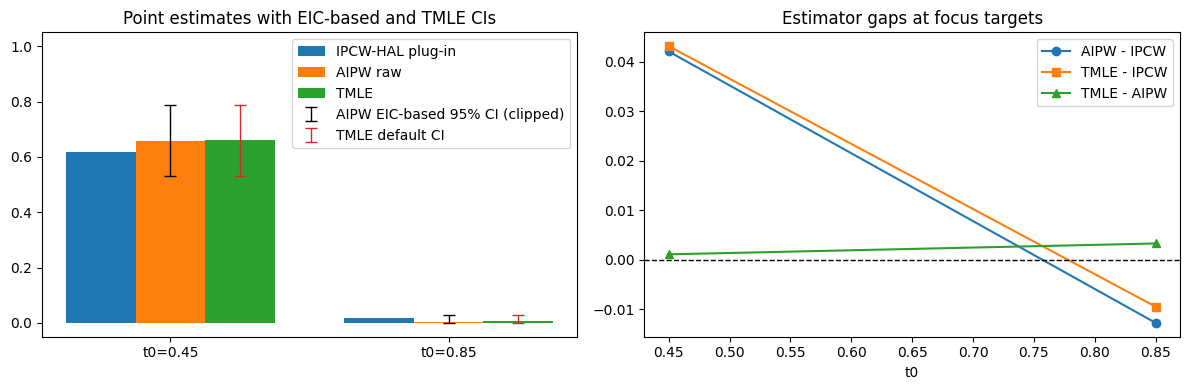

In [6]:
focus_tmle = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=FOCUS_T0S,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=False,
)

focus_tmle_summary = focus_tmle["summary"].rename(
    columns={
        "psi_star": "psi_tmle",
        "epsilon": "epsilon_hat",
        "converged": "tmle_converged",
        "ci_lower": "tmle_ci_lower_default",
        "ci_upper": "tmle_ci_upper_default",
        "eif_mean": "tmle_eif_mean",
    }
)[[
    "t0",
    "psi_tmle",
    "tmle_ci_lower_default",
    "tmle_ci_upper_default",
    "epsilon_hat",
    "tmle_converged",
    "tmle_eif_mean",
    "score_at_solution",
]]

focus_compare = focus_aipw_summary.merge(focus_tmle_summary, on="t0", how="left")
focus_compare["psi_tmle_minus_psi_ipcw"] = focus_compare["psi_tmle"] - focus_compare["psi_ipcw"]
focus_compare["psi_aipw_minus_psi_ipcw"] = focus_compare["psi_aipw_raw"] - focus_compare["psi_ipcw"]
focus_compare["psi_tmle_minus_psi_aipw"] = focus_compare["psi_tmle"] - focus_compare["psi_aipw_raw"]

display(
    focus_compare[
        [
            "t0",
            "psi_ipcw",
            "psi_aipw_raw",
            "eic_based_ci_lower",
            "eic_based_ci_upper",
            "psi_tmle",
            "tmle_ci_lower_default",
            "tmle_ci_upper_default",
            "if_mean_raw",
            "score_at_zero",
            "score_at_zero_over_n",
            "epsilon_hat",
            "tmle_converged",
            "abs_eif_mean",
            "aipw_out_of_bounds",
            "psi_tmle_minus_psi_aipw",
        ]
    ]
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [f"t0={t0:.2f}" for t0 in focus_compare["t0"]]
x = np.arange(len(labels))
width = 0.25

aipw_yerr = np.vstack(
    [
        focus_compare["psi_aipw_raw"] - focus_compare["eic_based_ci_lower"],
        focus_compare["eic_based_ci_upper"] - focus_compare["psi_aipw_raw"],
    ]
)
tmle_yerr = np.vstack(
    [
        focus_compare["psi_tmle"] - focus_compare["tmle_ci_lower_default"],
        focus_compare["tmle_ci_upper_default"] - focus_compare["psi_tmle"],
    ]
)

axes[0].bar(x - width, focus_compare["psi_ipcw"], width=width, label="IPCW-HAL plug-in")
axes[0].bar(x, focus_compare["psi_aipw_raw"], width=width, label="AIPW raw")
axes[0].bar(x + width, focus_compare["psi_tmle"], width=width, label="TMLE")
axes[0].errorbar(
    x,
    focus_compare["psi_aipw_raw"],
    yerr=aipw_yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.0,
    capsize=4,
    label="AIPW EIC-based 95% CI (clipped)",
)
axes[0].errorbar(
    x + width,
    focus_compare["psi_tmle"],
    yerr=tmle_yerr,
    fmt="none",
    ecolor="tab:red",
    elinewidth=1.0,
    capsize=4,
    label="TMLE default CI",
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylim(-0.05, 1.05)
axes[0].set_title("Point estimates with EIC-based and TMLE CIs")
axes[0].legend()

axes[1].plot(focus_compare["t0"], focus_compare["psi_aipw_minus_psi_ipcw"], marker="o", label="AIPW - IPCW")
axes[1].plot(focus_compare["t0"], focus_compare["psi_tmle_minus_psi_ipcw"], marker="s", label="TMLE - IPCW")
axes[1].plot(focus_compare["t0"], focus_compare["psi_tmle_minus_psi_aipw"], marker="^", label="TMLE - AIPW")
axes[1].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1].set_title("Estimator gaps at focus targets")
axes[1].set_xlabel("t0")
axes[1].legend()

plt.tight_layout()
plt.show()

## Phase 3: Curve-Level Comparison

After the phase-0 identity check, extend the validated pointwise helper across a target-time grid.

The plots below track:
- the three estimators over `t0`;
- correction size and residual score diagnostics;
- where TMLE and AIPW differ the most;
- whether that gap lines up with smaller censoring survival support.

,t0,psi_init,psi_ipcw,psi_aipw_raw,psi_aipw_clipped,if_mean_raw,estimand_variance,standard_error,eic_based_variance,eic_based_se,...,psi_tmle,tmle_ci_lower_default,tmle_ci_upper_default,epsilon_hat,tmle_converged,tmle_eif_mean,psi_tmle_minus_psi_ipcw,psi_aipw_minus_psi_ipcw,psi_tmle_minus_psi_aipw,tmle_minus_aipw_abs
0,0.050000,0.983043,0.983043,1.000027,1.000000,0.016984,7.609505e-08,0.000276,7.609505e-08,0.000276,...,1.000000,0.999459,1.000000,43.811626,True,-2.168404e-19,0.016957,0.016984,-0.000027,0.000027
1,0.114286,0.955661,0.955661,1.000026,1.000000,0.044365,1.069373e-06,0.001034,1.069373e-06,0.001034,...,1.000000,0.997973,1.000000,34.385588,True,5.464379e-18,0.044339,0.044365,-0.000026,0.000026
2,0.178571,0.920320,0.920320,0.986292,0.986292,0.065973,1.904350e-04,0.013800,1.904350e-04,0.013800,...,0.986315,0.959268,1.000000,1.701716,True,-1.956768e-16,0.065996,0.065973,0.000023,0.000023
3,0.242857,0.874706,0.874706,0.943263,0.943263,0.068557,7.680054e-04,0.027713,7.680054e-04,0.027713,...,0.943442,0.889125,0.997759,0.786969,True,1.740275e-15,0.068736,0.068557,0.000179,0.000179
4,0.307143,0.815834,0.815834,0.873625,0.873625,0.057791,1.676944e-03,0.040951,1.676944e-03,0.040951,...,0.874070,0.793807,0.954333,0.383005,True,-1.110223e-17,0.058236,0.057791,0.000445,0.000445


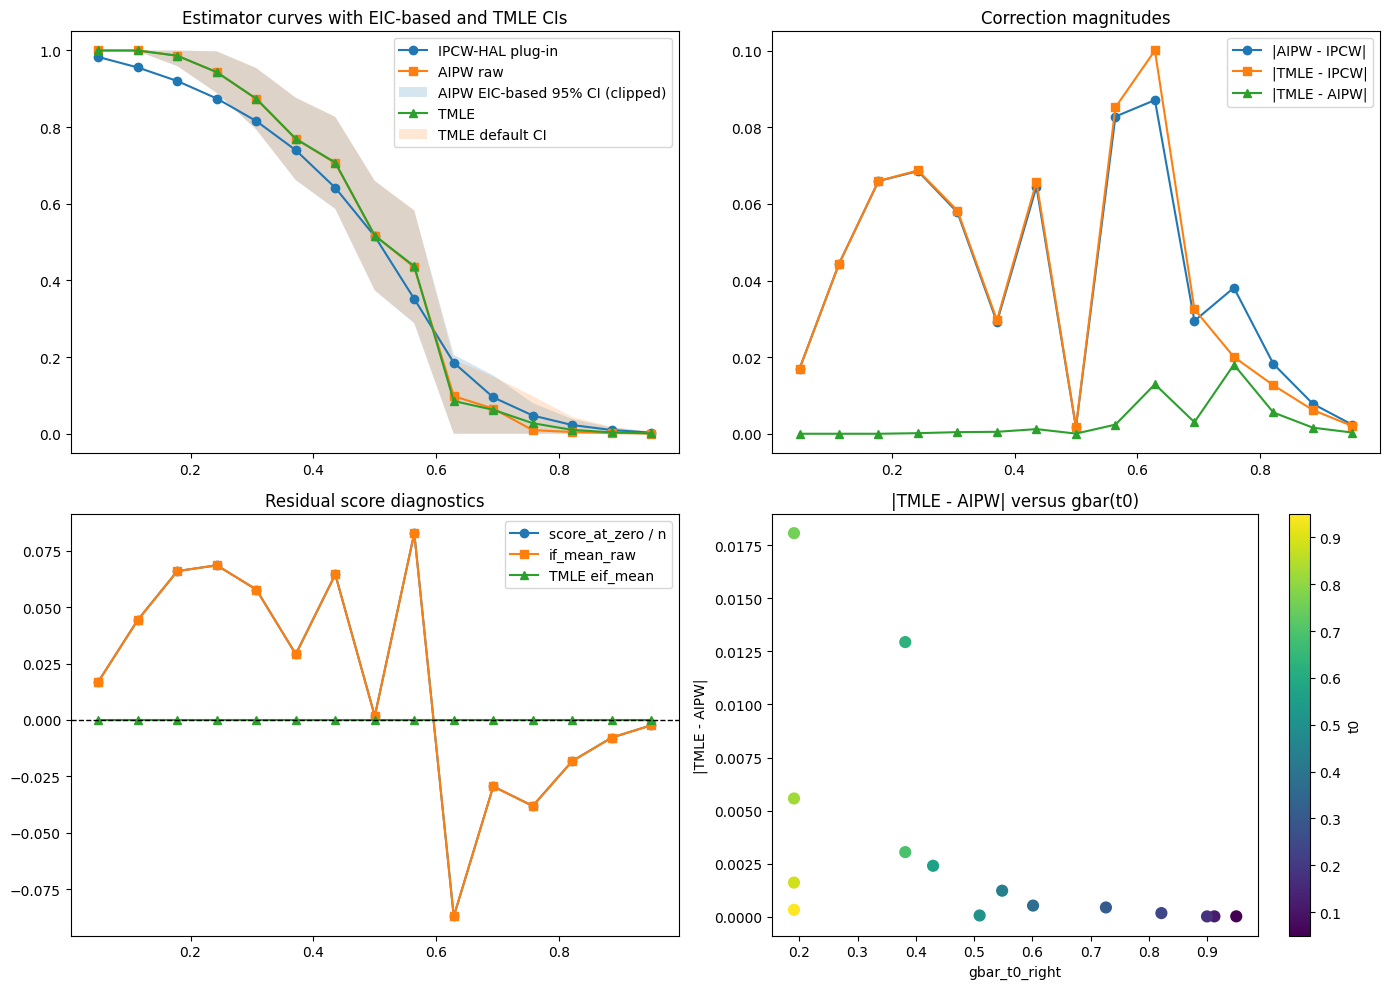

In [7]:
curve_aipw = right_censored_survival_aipw(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=TARGET_TIMES,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    store_pointwise_arrays=False,
)
curve_tmle = right_censored_survival_targeting_M_step(
    initial_estimator=stage1_estimator,
    observed_data=data,
    targeting_points=TARGET_TIMES,
    km=km_shared,
    clip=GBAR_CLIP,
    survival_clip=SURVIVAL_CLIP,
    eps_bracket_start=EPS_BRACKET_START,
    eps_bracket_growth=EPS_BRACKET_GROWTH,
    eps_bracket_max=EPS_BRACKET_MAX,
    eps_fallback_bounds=EPS_FALLBACK_BOUNDS,
    store_pointwise_arrays=False,
)
curve_tmle_summary = curve_tmle["summary"].rename(
    columns={
        "psi_star": "psi_tmle",
        "epsilon": "epsilon_hat",
        "converged": "tmle_converged",
        "ci_lower": "tmle_ci_lower_default",
        "ci_upper": "tmle_ci_upper_default",
        "eif_mean": "tmle_eif_mean",
    }
)[[
    "t0",
    "psi_tmle",
    "tmle_ci_lower_default",
    "tmle_ci_upper_default",
    "epsilon_hat",
    "tmle_converged",
    "tmle_eif_mean",
]]

curve_summary = curve_aipw["summary"].merge(curve_tmle_summary, on="t0", how="left")
curve_summary["psi_tmle_minus_psi_ipcw"] = curve_summary["psi_tmle"] - curve_summary["psi_ipcw"]
curve_summary["psi_aipw_minus_psi_ipcw"] = curve_summary["psi_aipw_raw"] - curve_summary["psi_ipcw"]
curve_summary["psi_tmle_minus_psi_aipw"] = curve_summary["psi_tmle"] - curve_summary["psi_aipw_raw"]
curve_summary["tmle_minus_aipw_abs"] = curve_summary["psi_tmle_minus_psi_aipw"].abs()

display(curve_summary.head())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(curve_summary["t0"], curve_summary["psi_ipcw"], marker="o", label="IPCW-HAL plug-in")
axes[0, 0].plot(curve_summary["t0"], curve_summary["psi_aipw_raw"], marker="s", label="AIPW raw")
axes[0, 0].fill_between(
    curve_summary["t0"],
    curve_summary["eic_based_ci_lower"],
    curve_summary["eic_based_ci_upper"],
    alpha=0.18,
    label="AIPW EIC-based 95% CI (clipped)",
)
axes[0, 0].plot(curve_summary["t0"], curve_summary["psi_tmle"], marker="^", label="TMLE")
axes[0, 0].fill_between(
    curve_summary["t0"],
    curve_summary["tmle_ci_lower_default"],
    curve_summary["tmle_ci_upper_default"],
    alpha=0.18,
    label="TMLE default CI",
)
axes[0, 0].set_ylim(-0.05, 1.05)
axes[0, 0].set_title("Estimator curves with EIC-based and TMLE CIs")
axes[0, 0].legend()

axes[0, 1].plot(curve_summary["t0"], curve_summary["psi_aipw_minus_psi_ipcw"].abs(), marker="o", label="|AIPW - IPCW|")
axes[0, 1].plot(curve_summary["t0"], curve_summary["psi_tmle_minus_psi_ipcw"].abs(), marker="s", label="|TMLE - IPCW|")
axes[0, 1].plot(curve_summary["t0"], curve_summary["tmle_minus_aipw_abs"], marker="^", label="|TMLE - AIPW|")
axes[0, 1].set_title("Correction magnitudes")
axes[0, 1].legend()

axes[1, 0].plot(curve_summary["t0"], curve_summary["score_at_zero_over_n"], marker="o", label="score_at_zero / n")
axes[1, 0].plot(curve_summary["t0"], curve_summary["if_mean_raw"], marker="s", label="if_mean_raw")
axes[1, 0].plot(curve_summary["t0"], curve_summary["tmle_eif_mean"], marker="^", label="TMLE eif_mean")
axes[1, 0].axhline(0.0, color="black", linewidth=1.0, linestyle="--")
axes[1, 0].set_title("Residual score diagnostics")
axes[1, 0].legend()

scatter = axes[1, 1].scatter(
    curve_summary["gbar_t0_right"],
    curve_summary["tmle_minus_aipw_abs"],
    c=curve_summary["t0"],
    cmap="viridis",
    s=60,
)
axes[1, 1].set_title("|TMLE - AIPW| versus gbar(t0)")
axes[1, 1].set_xlabel("gbar_t0_right")
axes[1, 1].set_ylabel("|TMLE - AIPW|")
fig.colorbar(scatter, ax=axes[1, 1], label="t0")

plt.tight_layout()
plt.show()

## Promotion Gate

The notebook should only motivate a later package-level AIPW wrapper if all of the following look acceptable:
- the semantic identity check passes;
- AIPW is not just a relabeling of the current TMLE outputs;
- the curve-level differences are interpretable rather than accidental;
- the tail behavior remains readable through the EIC-based diagnostics.

The summary cell below turns those questions into a compact notebook verdict.

In [8]:
max_tmle_aipw_gap_idx = int(curve_summary["tmle_minus_aipw_abs"].idxmax())
promotion_gate = pd.Series(
    {
        "semantic_identity_passed": bool(identity_passed),
        "max_abs_analytic_vs_api_gap": float(identity_summary["max_abs_diff_analytic_vs_api"].max()),
        "max_abs_score_gap": float(identity_summary["abs_score_gap"].max()),
        "max_abs_tmle_minus_aipw": float(curve_summary["tmle_minus_aipw_abs"].max()),
        "max_abs_aipw_minus_ipcw": float(curve_summary["psi_aipw_minus_psi_ipcw"].abs().max()),
        "any_aipw_out_of_bounds": bool(curve_summary["aipw_out_of_bounds"].any()),
        "largest_tmle_aipw_gap_t0": float(curve_summary.loc[max_tmle_aipw_gap_idx, "t0"]),
        "gbar_at_largest_gap": float(curve_summary.loc[max_tmle_aipw_gap_idx, "gbar_t0_right"]),
    },
    name="value",
)
display(promotion_gate.to_frame())

if identity_passed:
    print(
        "Verdict: the notebook prototype supports a later separate AIPW wrapper if the curve-level gaps look substantively useful."
    )
else:
    print(
        "Verdict: keep this in the notebook only and do not promote it until the semantic identity is resolved."
    )

,value
semantic_identity_passed,True
max_abs_analytic_vs_api_gap,0.0
max_abs_score_gap,0.0
max_abs_tmle_minus_aipw,0.018066
max_abs_aipw_minus_ipcw,0.087096
any_aipw_out_of_bounds,True
largest_tmle_aipw_gap_t0,0.757143
gbar_at_largest_gap,0.190967


Verdict: the notebook prototype supports a later separate AIPW wrapper if the curve-level gaps look substantively useful.
